In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
data=pd.read_csv('insurance.csv')

In [5]:
data

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [6]:
#EDA

In [7]:
data.shape

(1338, 7)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
data.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [10]:
data.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [11]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [12]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')

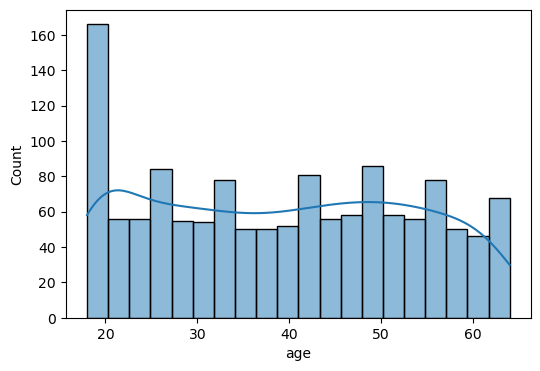

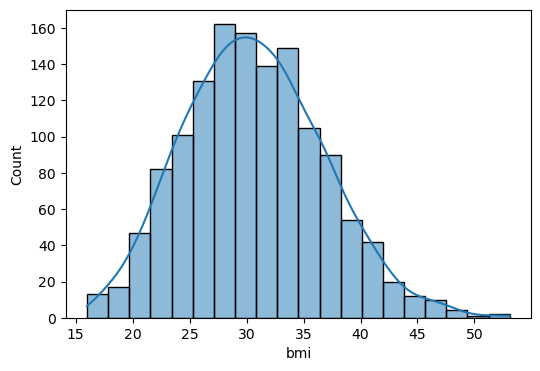

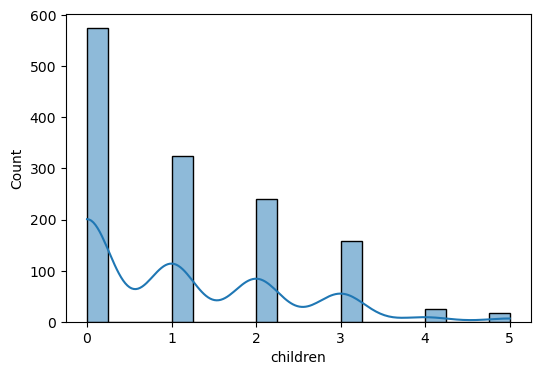

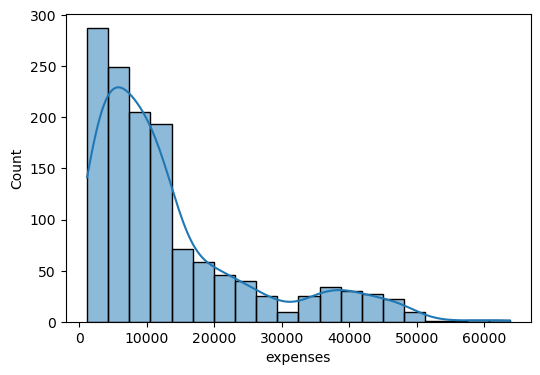

In [13]:
numeric_columns=['age', 'bmi', 'children', 'expenses']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col],kde=True,bins=20)

<Axes: xlabel='children', ylabel='count'>

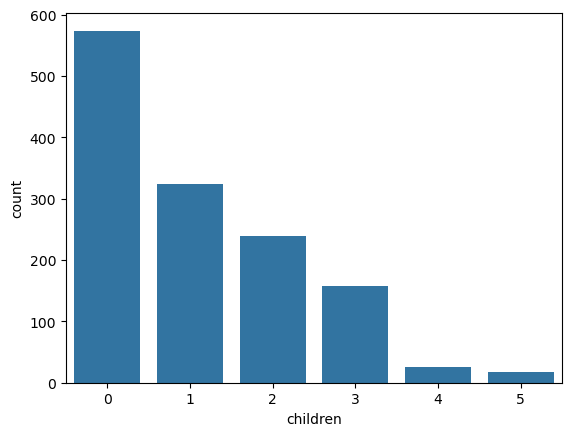

In [14]:
sns.countplot(x=data['children'])

<Axes: xlabel='sex', ylabel='count'>

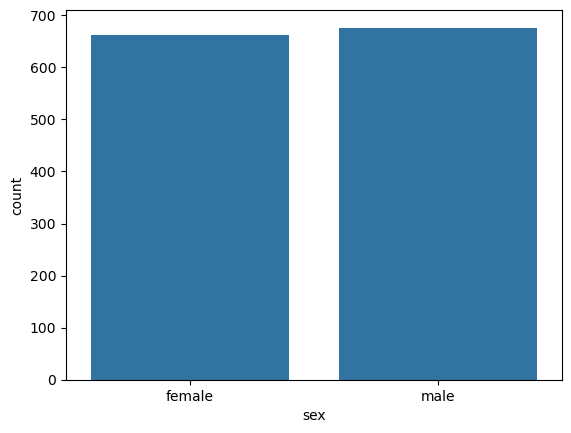

In [15]:
sns.countplot(x=data['sex'])

<Axes: xlabel='smoker', ylabel='count'>

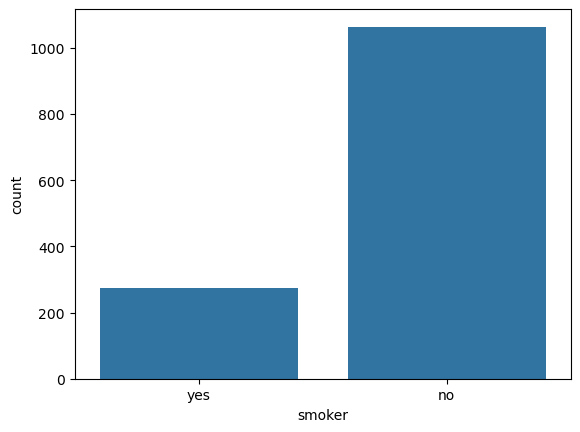

In [16]:
sns.countplot(x=data['smoker'])

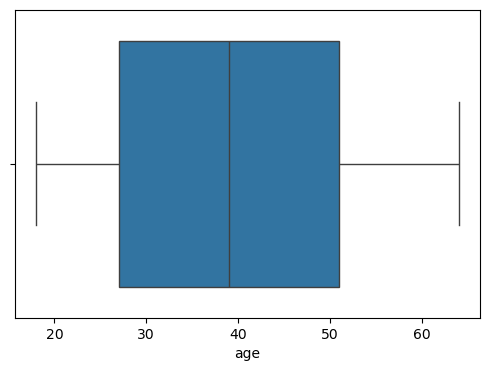

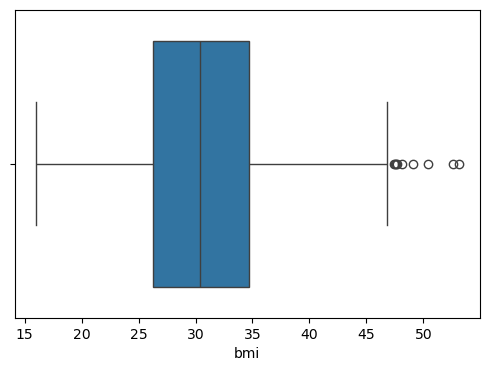

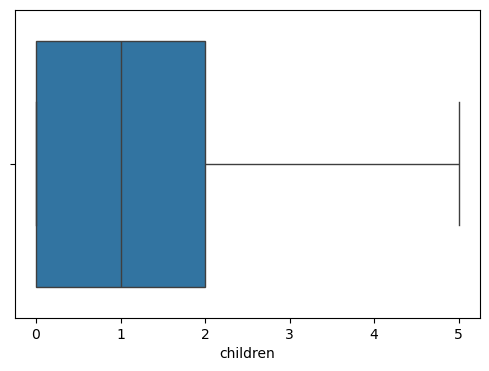

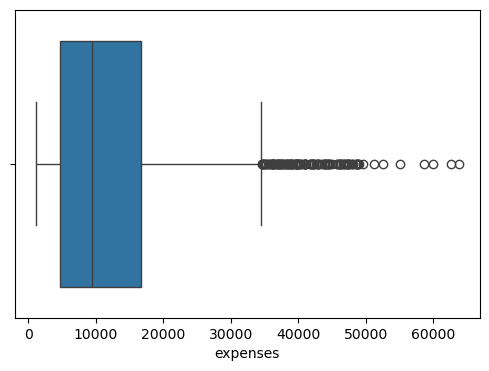

In [17]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])

<Axes: >

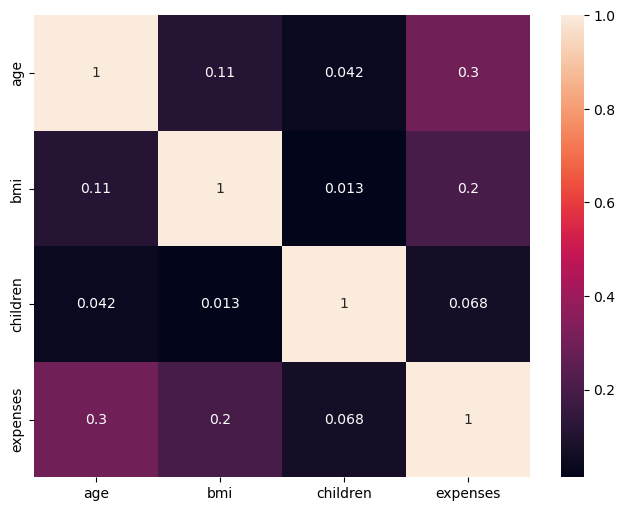

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True),annot=True)

In [19]:
#cleaning and preprocessing

In [20]:
data_cleaned=data.copy()

In [21]:
data_cleaned.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [22]:
data_cleaned.shape

(1338, 7)

In [23]:
data_cleaned.drop_duplicates(inplace=True)

In [24]:
data_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [25]:
data_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
expenses    float64
dtype: object

In [26]:
data_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [27]:
data_cleaned['sex'] = data_cleaned['sex'].map({"male":0,"female":1})

In [28]:
data_cleaned.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,1,27.9,0,yes,southwest,16884.92
1,18,0,33.8,1,no,southeast,1725.55
2,28,0,33.0,3,no,southeast,4449.46
3,33,0,22.7,0,no,northwest,21984.47
4,32,0,28.9,0,no,northwest,3866.86


In [29]:
data_cleaned['smoker'] = data_cleaned['smoker'].map({"no":0,"yes":1})

In [30]:
data_cleaned.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,1,27.9,0,1,southwest,16884.92
1,18,0,33.8,1,0,southeast,1725.55
2,28,0,33.0,3,0,southeast,4449.46
3,33,0,22.7,0,0,northwest,21984.47
4,32,0,28.9,0,0,northwest,3866.86


In [31]:
data_cleaned.rename(columns={'sex':'is_female','smoker':'is_smoker'},inplace=True)

In [32]:
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,expenses
0,19,1,27.9,0,1,southwest,16884.92
1,18,0,33.8,1,0,southeast,1725.55
2,28,0,33.0,3,0,southeast,4449.46
3,33,0,22.7,0,0,northwest,21984.47
4,32,0,28.9,0,0,northwest,3866.86


In [33]:
data_cleaned=pd.get_dummies(data_cleaned,columns=['region'],drop_first=True)

In [34]:
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest
0,19,1,27.9,0,1,16884.92,False,False,True
1,18,0,33.8,1,0,1725.55,False,True,False
2,28,0,33.0,3,0,4449.46,False,True,False
3,33,0,22.7,0,0,21984.47,True,False,False
4,32,0,28.9,0,0,3866.86,True,False,False


In [35]:
data_cleaned=data_cleaned.astype(int)

In [36]:
data_cleaned.head(5)

,age,is_female,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


In [37]:
data_cleaned.shape

(1337, 9)

FEATURE ENGINEERING


In [38]:
data_cleaned

,age,is_female,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,31,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


<Axes: xlabel='bmi', ylabel='Count'>

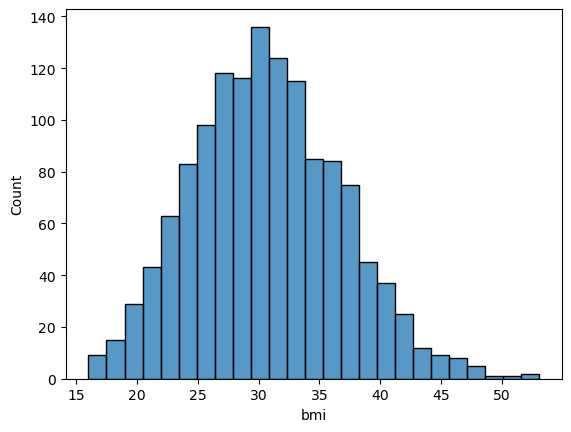

In [39]:
sns.histplot(data['bmi'])

In [40]:
data_cleaned['bmi_category'] =pd.cut(
    data_cleaned['bmi'],
    bins=[0, 18.5, 24.9,29.9,float('inf')],
    labels=['underweight','normal','overweight','obese']
)

In [41]:
data_cleaned

,age,is_female,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,31,3,0,10600,1,0,0,obese
1334,18,1,31,0,0,2205,0,0,0,obese
1335,18,1,36,0,0,1629,0,1,0,obese
1336,21,1,25,0,0,2007,0,0,1,overweight


In [42]:
data_cleaned= pd.get_dummies(data_cleaned,columns=['bmi_category'],drop_first=True)

In [43]:
data_cleaned=data_cleaned.astype(int)

In [44]:
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [45]:
data_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'expenses',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'],
      dtype='object')

sklearn

In [46]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scaler= StandardScaler()

data_cleaned[cols]=scaler.fit_transform(data_cleaned[cols])

In [47]:
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.524321,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.457496,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.457496,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.342502,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.360685,-0.909234,0,3866,1,0,0,0,1,0


In [48]:
from scipy.stats import pearsonr

selected_features=[
       'age', 'is_female', 'bmi', 'children', 'is_smoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'

]

correlations ={
              feature:pearsonr(data_cleaned[feature],data_cleaned['expenses'])[0]
              for feature in selected_features
}
correlation_data= pd.DataFrame(list(correlations.items()),columns=['Features','Pearson Correlation'])
correlation_data.sort_values(by='Pearson Correlation',ascending=False)

,Features,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_obese,0.200347
2,bmi,0.197714
6,region_southeast,0.073577
3,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
1,is_female,-0.058046
8,bmi_category_normal,-0.104283


In [49]:
cat_features=[
       'is_female',  'children', 'is_smoker', 
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'
]

In [50]:
from scipy.stats import chi2_contingency
import pandas as pd


alpha = 0.05

data_cleaned['charges_bin'] = pd.qcut(data_cleaned['expenses'], q=4, labels=False)


chi2_results = {}

for col in cat_features:
    
    # contingency table
    contingency = pd.crosstab(data_cleaned[col], data_cleaned['charges_bin'])
    
    # chi-square test
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency)
    
    # decision
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    
    # store results
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }


chi2_df = pd.DataFrame(chi2_results).T


chi2_df = chi2_df.sort_values(by='p_value')

chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
children,138.659313,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_overweight,4.873307,0.181313,Accept Null (Drop Feature)
bmi_category_normal,4.231793,0.237498,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [51]:
final_df=data_cleaned[['age','is_female', 'bmi', 'children', 'is_smoker', 'expenses',
  'region_southeast',  'bmi_category_obese']]

In [52]:
final_df

,age,is_female,bmi,children,is_smoker,expenses,region_southeast,bmi_category_obese
0,-1.440418,1,-0.524321,-0.909234,1,16884,0,0
1,-1.511647,0,0.457496,-0.079442,0,1725,1,1
2,-0.799350,0,0.457496,1.580143,0,4449,1,1
3,-0.443201,0,-1.342502,-0.909234,0,21984,0,0
4,-0.514431,0,-0.360685,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,0.130224,1.580143,0,10600,0,1
1334,-1.511647,1,0.130224,-0.909234,0,2205,0,1
1335,-1.511647,1,0.948405,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.851594,-0.909234,0,2007,0,0


In [53]:
X = final_df.drop('expenses', axis=1)
y = final_df['expenses']

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 :", r2_score(y_test, y_pred_lr))

Linear Regression
MAE : 4294.939713009356
RMSE: 6000.43704215957
R2 : 0.8040596314609438


In [57]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2 Score:", r2_score(y_test, y_pred_ridge))

Ridge Regression
MAE: 4302.716077366026
RMSE: 6014.791316239327
R2 Score: 0.8031210511977903


In [58]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0, max_iter=10000)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2 Score:", r2_score(y_test, y_pred_lasso))

Lasso Regression
MAE: 4294.720278149217
RMSE: 6001.232022187297
R2 Score: 0.8040077089102418


In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Random Forest Regression")
print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Regression
MAE : 2837.399504856669
RMSE: 4969.528716743052
R2 Score: 0.8656033130741505


In [63]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2 Score:", r2_score(y_test, y_pred_xgb))

XGBoost Regression
MAE: 2462.3642578125
RMSE: 4268.190483097023
R2 Score: 0.9008607268333435


In [64]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ]
})

comparison.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score
5,XGBoost,0.900861
4,Random Forest,0.865603
0,Linear Regression,0.804060
2,Lasso Regression,0.804008
1,Ridge Regression,0.803121
3,Decision Tree,0.734169


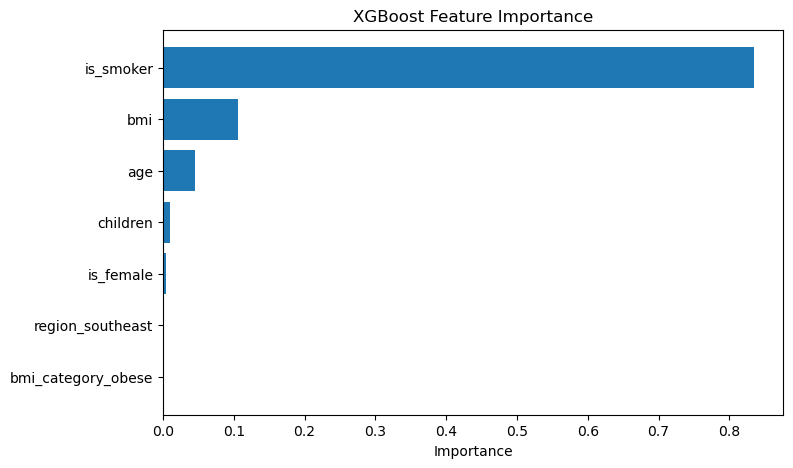

In [65]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

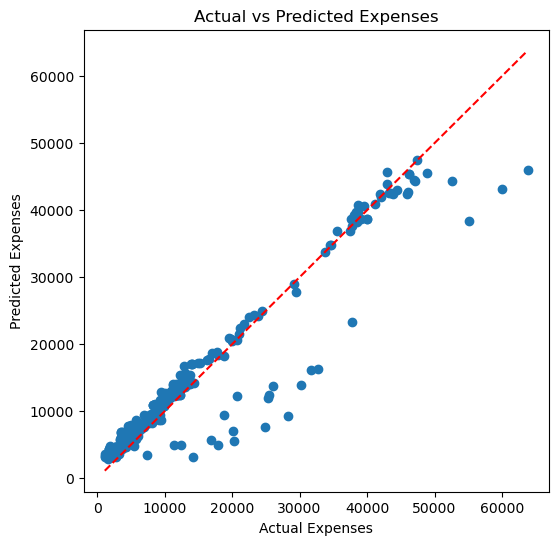

In [66]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb)
plt.xlabel("Actual Expenses")
plt.ylabel("Predicted Expenses")
plt.title("Actual vs Predicted Expenses")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.show()

In [67]:
import joblib

joblib.dump(xgb, "insurance_expense_model.pkl")

['insurance_expense_model.pkl']